# Day 7 — How Indian Summers Hurt Refrigerator Efficiency
**Mahesha Gonal — Refrigeration Simulation Portfolio**

**In plain terms:** a refrigerator doesn't get to choose its condensing temperature — it's forced up by whatever the kitchen ambient temperature is, plus a fixed margin the condenser needs to actually reject heat (modelled here as **ambient + 12°C**). This notebook sweeps ambient temperature from a mild 25°C up to a brutal 55°C (a realistic Indian summer extreme) and tracks three things: **COP**, **compressor work**, and **annual electricity consumption**.

**Refrigerant:** R600a | **Evaporator fixed at -25°C** | **Cooling load: 80 W**

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

In [2]:
# CELL 2 — Imports
import CoolProp.CoolProp as CP
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — Reusable cycle function
def calculate_cycle(T_evap_C, T_cond_C, refrigerant="R600a"):
    T_evap = T_evap_C + 273.15
    T_cond = T_cond_C + 273.15
    P_evap = CP.PropsSI("P","T",T_evap,"Q",1,refrigerant)
    P_cond = CP.PropsSI("P","T",T_cond,"Q",1,refrigerant)
    h1 = CP.PropsSI("H","T",T_evap,"Q",1,refrigerant)
    s1 = CP.PropsSI("S","T",T_evap,"Q",1,refrigerant)
    h2 = CP.PropsSI("H","P",P_cond,"S",s1,refrigerant)
    h3 = CP.PropsSI("H","T",T_cond,"Q",0,refrigerant)
    h4 = h3
    COP = (h1-h4)/(h2-h1)
    m_dot = 100/(h1-h4)
    return COP, m_dot, h1, h2, h3, h4, P_evap, P_cond

In [4]:
# CELL 4 — Sweep ambient temperature, T_cond = T_ambient + 12C
T_evap = -25
refrigerant = "R600a"
T_ambient_range = np.linspace(25, 55, 30)
T_cond_range = T_ambient_range + 12

COP_list, compressor_work_list, annual_energy_list = [], [], []

for T_amb, T_cond in zip(T_ambient_range, T_cond_range):
    try:
        COP, m_dot, h1, h2, h3, h4, P_evap, P_cond = calculate_cycle(T_evap, T_cond, refrigerant)
        W_comp = (h2-h1)/1000
        duty_cycle = 80/100
        W_input = 80/COP
        annual_energy = (W_input * duty_cycle * 8760)/1000
        COP_list.append(COP)
        compressor_work_list.append(W_comp)
        annual_energy_list.append(annual_energy)
    except:
        COP_list.append(None)
        compressor_work_list.append(None)
        annual_energy_list.append(None)

print(f"At 25C ambient: COP={COP_list[0]:.2f}  Annual energy={annual_energy_list[0]:.1f} kWh")
print(f"At 55C ambient: COP={COP_list[-1]:.2f}  Annual energy={annual_energy_list[-1]:.1f} kWh")

At 25C ambient: COP=2.95  Annual energy=189.9 kWh
At 55C ambient: COP=1.44  Annual energy=388.7 kWh


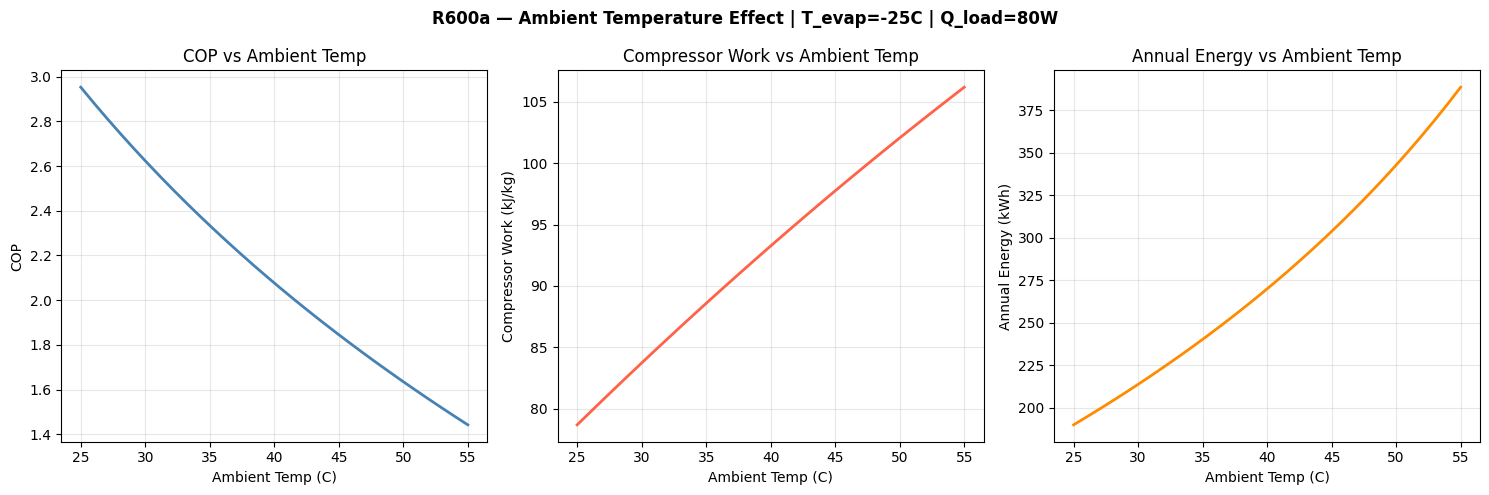

In [5]:
# CELL 5 — Three-panel plot
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].plot(T_ambient_range, COP_list, color="steelblue", linewidth=2)
axes[0].set_title("COP vs Ambient Temp")
axes[0].set_xlabel("Ambient Temp (C)")
axes[0].set_ylabel("COP")
axes[0].grid(True, alpha=0.3)

axes[1].plot(T_ambient_range, compressor_work_list, color="tomato", linewidth=2)
axes[1].set_title("Compressor Work vs Ambient Temp")
axes[1].set_xlabel("Ambient Temp (C)")
axes[1].set_ylabel("Compressor Work (kJ/kg)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(T_ambient_range, annual_energy_list, color="darkorange", linewidth=2)
axes[2].set_title("Annual Energy vs Ambient Temp")
axes[2].set_xlabel("Ambient Temp (C)")
axes[2].set_ylabel("Annual Energy (kWh)")
axes[2].grid(True, alpha=0.3)

fig.suptitle("R600a — Ambient Temperature Effect | T_evap=-25C | Q_load=80W", fontweight="bold")
plt.tight_layout()
plt.savefig("day07_ambient_effect.png", dpi=150)
plt.show()

**What this graph tells us:** all three curves move in the direction you'd expect from a hotter kitchen — COP drops, compressor work climbs, and annual electricity use rises steadily. The practical point: **BEE star ratings are tested at a fixed lab ambient**, but a real fridge in a non-AC Indian kitchen routinely sees ambients well above that test condition during summer. The gap between the *rated* energy number on the yellow label and the *actual* energy a customer pays for in June is largely explained by this one curve.

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day07_ambient_temperature_effect.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 07 - ambient temperature effect on COP, work, annual energy", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 07 - ambient temperature effect on COP, work, annual energy", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")
